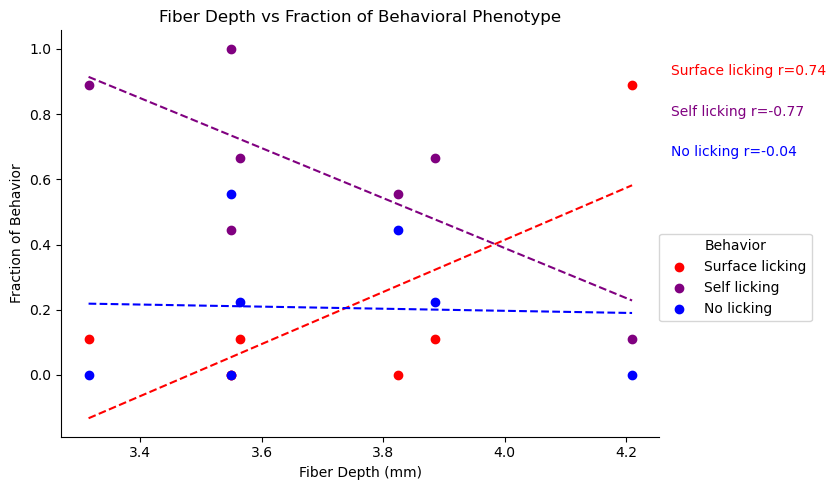

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

# Load the data from the Excel file
file_path = 'prefBehaviorByMouse_wDepths_onlyConfirmedFibers.csv'
data = pd.read_csv(file_path)

# Extract relevant columns
stim_columns = data.columns[1:10]  # Automatically detect stimulation columns
fiber_depth_column = 'FiberDepthMean'

# Function to calculate the fraction of each behavior
def calculate_behavior_fractions(row):
    behaviors = row[stim_columns].values
    total_stimulations = len(behaviors)
    if total_stimulations == 0:
        return pd.Series([np.nan, np.nan, np.nan])
    surface_licking_fraction = np.sum(behaviors == 'Surface licking') / total_stimulations
    self_licking_fraction = np.sum(behaviors == 'Self licking') / total_stimulations
    no_licking_fraction = np.sum(behaviors == 'no licking') / total_stimulations
    return pd.Series([surface_licking_fraction, self_licking_fraction, no_licking_fraction])

# Apply the function to calculate fractions
fractions = data.apply(calculate_behavior_fractions, axis=1)
fractions.columns = ['Surface licking', 'Self licking', 'No licking']

# Add fiber depth to the fractions DataFrame
fractions['FiberDepthMean'] = data[fiber_depth_column]

# Plotting
plt.figure(figsize=(10, 5))

# Colors for each behavior
colors = {'Surface licking': 'red', 'Self licking': 'purple', 'No licking': 'blue'}

# Plot each behavior
for idx, behavior in enumerate(['Surface licking', 'Self licking', 'No licking']):
    # Filter out NaN values for current behavior and FiberDepthMean
    mask = ~fractions[behavior].isna() & ~fractions['FiberDepthMean'].isna()
    x = fractions.loc[mask, 'FiberDepthMean']
    y = fractions.loc[mask, behavior]
    plt.scatter(x, y, color=colors[behavior], label=behavior)
    
    if len(x) > 1 and len(y) > 1:
        # Sort x for smooth trend line plotting
        sorted_idx = np.argsort(x)
        x_sorted = x.iloc[sorted_idx]
        # Calculate and plot trend line
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x_sorted, p(x_sorted), linestyle='dashed', color=colors[behavior])
        # Calculate Pearson correlation coefficient
        r, _ = pearsonr(x, y)
        # Place correlation text outside plot area (right of plot)
        plt.text(1.02, 0.9 - 0.1 * idx, f'{behavior} r={r:.2f}', color=colors[behavior], transform=plt.gca().transAxes, ha='left', va='center')
    else:
        plt.text(1.02, 0.9 - 0.1 * idx, f'{behavior} (insufficient data)', color=colors[behavior], transform=plt.gca().transAxes, ha='left', va='center')

plt.xlabel('Fiber Depth (mm)')
plt.ylabel('Fraction of Behavior')
plt.title('Fiber Depth vs Fraction of Behavioral Phenotype')
# Move legend outside plot area (bottom right)
plt.legend(title='Behavior', bbox_to_anchor=(1.00, 0.5), loc='best', borderaxespad=0)
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Remove grid
plt.grid(False)
# Despine
sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
